# Introduction

In this tutorial, we will learn about time series modeling. 

In the broadest sense, a time series model is simply a model that explicitly includes time. "Including time", of course, can mean lots of things. For example, we might literally put time into the model as a feature. Calling our variable of interest $y_t$, we might say that $y_t$ follows a *deterministic trend*, or:

$$ y_t = \alpha + \beta t + \varepsilon_t $$

In [1]:
import sys

if "google.colab" in sys.modules:
    !pip install git+https://github.com/pymc-devs/pymc-extras.git@main
    !pip install nutpie
    !pip install watermark

import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor
import pytensor.tensor as pt

warnings.filterwarnings(action="ignore", category=UserWarning)

plt.rcParams.update(
    {
        "figure.figsize": (14, 4),
        "figure.dpi": 144,
        "axes.grid": True,
        "grid.linewidth": 0.5,
        "grid.linestyle": "--",
        "axes.spines.top": False,
        "axes.spines.bottom": False,
        "axes.spines.left": False,
        "axes.spines.right": False,
    }
)


SEED = sum(map(ord, "Intro to Statespace"))
rng = np.random.default_rng(SEED)

## Simple Linear State-Space Model (SSM)

This code sets up a Bayesian state-space model (SSM) in PyMC where we're simulating a deterministic linear trend in time-series data. Instead of starting with real data, we're generating fake data from the prior predictive distribution.

We’ve built a simple **linear SSM** where observations follow a Gaussian distribution around a linear trend:

$$
y_t \sim \mathcal{N}(\alpha + \beta t,\ \sigma^2)
$$

**Interpretation**

- $\alpha$: baseline level at time $t=0$  
- $\beta$: slope over time  
- $\sigma$: noise (observation variability)  
- $y_t$: observed or simulated data at time $t$

Right now, the trend $\mu_t = \alpha + \beta t$ is **deterministic** (a straight line), while the observations are **random** due to the Gaussian noise $\sigma$.


### How this fits into SSMs?


**Observation equation**
$$
y_t = \mu_t + \varepsilon_t,\qquad \varepsilon_t \sim \mathcal{N}(0,\ \sigma^2)
$$

**State equation (stochastic trend)**
$$
\mu_t = \mu_{t-1} + \eta_t,\qquad \eta_t \sim \mathcal{N}(0,\ \tau^2)
$$

Making the state equation stochastic turns the trend $\mu_t$ into a **Gaussian Random Walk**.  
Here, $\tau^2$ controls how much the latent state can drift between time steps.





## Forecasting

Sampling: [alpha, beta, sigma, y_hat]


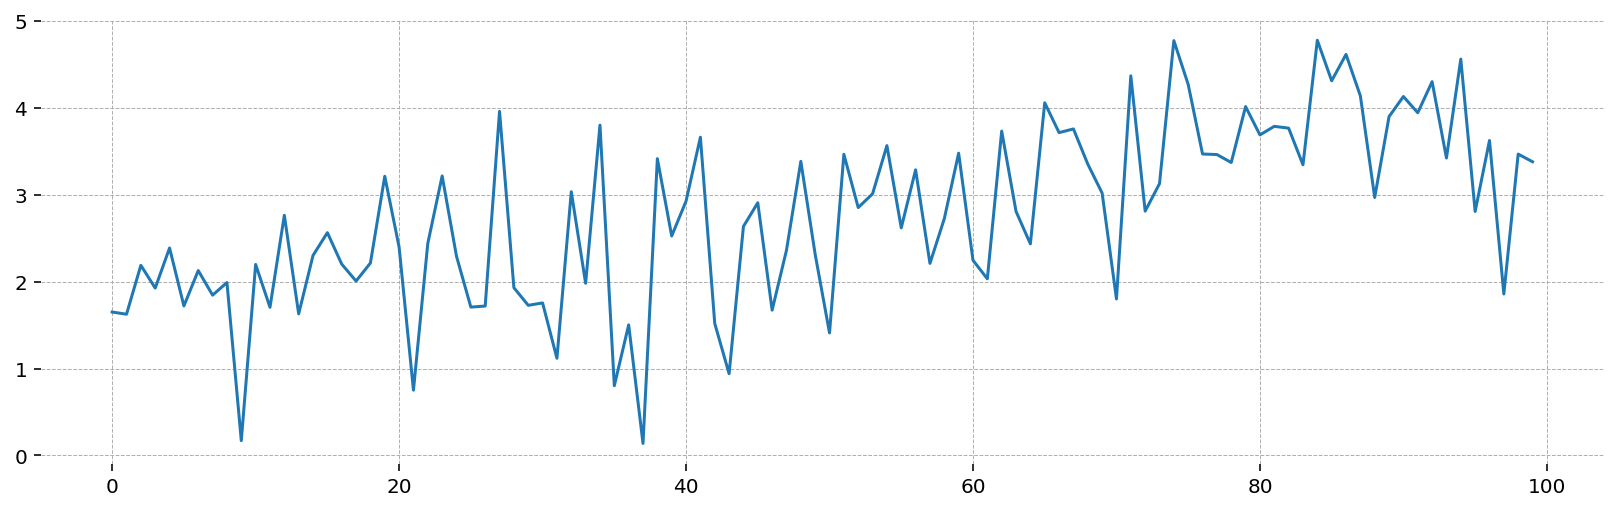

In [2]:
coords = {"time": range(100)}
with pm.Model(coords=coords) as deterministic_trend:
    t = pm.Data("t", range(100), dims=["time"])
    alpha = pm.Normal("alpha", mu=3, sigma=1)
    beta = pm.HalfNormal("beta", sigma=0.1)
    mu = pm.Deterministic("mu", alpha + beta * t, dims=["time"])

    sigma = pm.Exponential("sigma", 1)
    y_hat = pm.Normal("y_hat", mu=mu, sigma=sigma, dims=["time"])
    prior = pm.sample_prior_predictive(draws=1, random_seed=rng)

data = prior.prior.y_hat.values.squeeze()
plt.plot(data);

In [4]:
# We're using PyMC’s pm.observe context manager to reuse an existing model 
# (deterministic_trend) but this time attach data to the variable 
# y_hat so you can actually perform inference.

with pm.observe(
    deterministic_trend, {"y_hat": prior.prior.y_hat.values.squeeze()}
) as deterministic_trend_obs:
    idata = pm.sample(compile_kwargs={"mode": "NUMBA"}, random_seed=rng)
    idata = pm.sample_posterior_predictive(
        idata, extend_inferencedata=True, random_seed=rng
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
Sampling: [y_hat]


Output()

The types of things you want to do with a time series models are sometimes different from what is done with a "normal" model. For one, we want to be able to say something about the future. Time-as-feature models are attractive, because it is trivial to know the future values of the time variable: it marches forward. We can directly replace the training time with an out-of-sample time and generate forecasts.

In [ ]:
# Forecasting future values with your PyMC state-space model after you’ve already fitted it

with deterministic_trend_obs:
    pm.set_data({"t": range(100, 120)}, coords={"time": range(100, 120)})
    forecast = pm.sample_posterior_predictive(
        idata, extend_inferencedata=False, predictions=True, random_seed=rng
    )

Sampling: [y_hat]


Output()

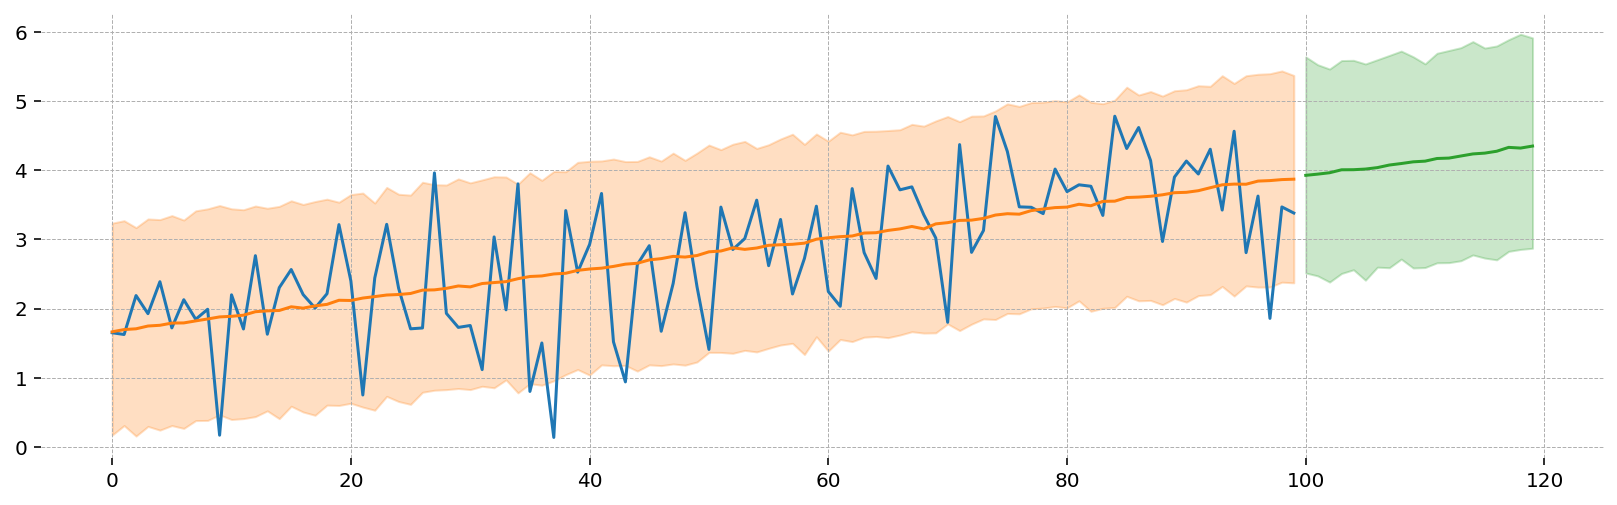

In [ ]:
# Xisualize your entire Bayesian workflow — observed data, model fit, and forecasted predictions

fig, ax = plt.subplots(figsize=(14, 4), dpi=144)
ax.plot(data)

mu = idata.posterior_predictive.y_hat.mean(dim=["chain", "draw"])
hdi = az.hdi(idata.posterior_predictive).y_hat

ax.plot(mu)
ax.fill_between(range(100), *hdi.values.T, color="tab:orange", alpha=0.25)

forecast_mu = forecast.predictions.y_hat.mean(dim=["chain", "draw"])
forecast_hdi = az.hdi(forecast.predictions).y_hat
ax.plot(range(100, 120), forecast_mu)
ax.fill_between(range(100, 120), *forecast_hdi.values.T, color="tab:green", alpha=0.25)
plt.show()

This example is extremely simple, but it can be extended in powerful ways by pumping time values of time through arbitrarily complex functions. Examples include the Prophet model, which transform the time counter into a time-varying trend and sinusoidal seasonal waves.

Gaussian Processes are another example -- these pump the time counter through a **kernel function**, and evaluates datapoints as "similar" or "different" based on their distance in the kernel space.

Time-as-feature models have a lot of advantages. At the end of the day, many of them are just basic linear projections (not GPs though). As such, they fit quickly, scale well, and can be trivially parallelized for minibatching and hardware acceleration. 

This example is about time-as-feature models.